# `Baseline` 

## Import `YOLO`

In [70]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
import ssl
ssl._create_default_https_context = ssl._create_stdlib_context

In [72]:
import matplotlib.pyplot as plt
import cv2

In [73]:
# !pip3 install -U ultralytics --user

In [74]:
import ultralytics

In [75]:
from ultralytics import settings
settings.update({"wandb": False, "tensorboard": False, "clearml":False, "mlflow":False, "neptune":False, 'comet': False, 'dvc': False, 'hub': False })

In [76]:
print(settings)

JSONDict("C:\Users\Ronkin\AppData\Roaming\Ultralytics\settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "D:\\Yandex Disk\\ОК Анализ данных и ИИ\\Авторские материалы\\Практические задания\\7. Обучение НС\\datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "3aa6c817d51332216d991dfaf6bdbd6e6b585ffdfef3304581f656d4f07673d9",
  "sync": true,
  "api_key": "",
  "openai_api_key": "",
  "clearml": false,
  "comet": false,
  "dvc": false,
  "hub": false,
  "mlflow": false,
  "neptune": false,
  "raytune": false,
  "tensorboard": false,
  "wandb": false,
  "vscode_msg": true
}


In [77]:
ultralytics.checks()

Ultralytics 8.3.127  Python-3.12.7 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
Setup complete  (28 CPUs, 31.8 GB RAM, 270.3/952.8 GB disk)


In [78]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [79]:
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [80]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [81]:
from urllib.request import urlretrieve
from torchvision.datasets.utils import download_and_extract_archive

## dataset

In [82]:
root_path = Path(os.getcwd()) 
print(list(root_path.iterdir()))

[WindowsPath('C:/Users/Ronkin/Documents/GitHub/Deep-Learning-in-Image-Processing-Lectures/2025/.ipynb_checkpoints'), WindowsPath('C:/Users/Ronkin/Documents/GitHub/Deep-Learning-in-Image-Processing-Lectures/2025/7_2_YOLOv12.ipynb'), WindowsPath('C:/Users/Ronkin/Documents/GitHub/Deep-Learning-in-Image-Processing-Lectures/2025/7_2_Учебное задание и его проверка.ipynb'), WindowsPath('C:/Users/Ronkin/Documents/GitHub/Deep-Learning-in-Image-Processing-Lectures/2025/base_line_EN.ipynb'), WindowsPath('C:/Users/Ronkin/Documents/GitHub/Deep-Learning-in-Image-Processing-Lectures/2025/best.pt'), WindowsPath('C:/Users/Ronkin/Documents/GitHub/Deep-Learning-in-Image-Processing-Lectures/2025/craters'), WindowsPath('C:/Users/Ronkin/Documents/GitHub/Deep-Learning-in-Image-Processing-Lectures/2025/Craters_Project_baseline_and_task.ipynb'), WindowsPath('C:/Users/Ronkin/Documents/GitHub/Deep-Learning-in-Image-Processing-Lectures/2025/Craters_project_Cheker.ipynb'), WindowsPath('C:/Users/Ronkin/Documents/Gi

In [84]:
url = "https://github.com/MVRonkin/Deep-Learning-Foundation-Course/raw/refs/heads/main/DLUtilits/craters.zip"

archive_name = url.split('/')[-1]
root_directory = os.path.join(os.getcwd(),'datasets')
dataset_directory = os.path.splitext(os.path.join(root_directory,archive_name))[0]

if not os.path.exists(dataset_directory):
    download_and_extract_archive(url, root_directory)

print(os.listdir(dataset_directory))

100%|█████████████████████████████████████████████████████████████████████████████████████| 1.34k/1.34k [00:00<?, ?B/s]

['test', 'train', 'valid']


### путь к тренировочной и к валидационной части

In [85]:
ext = 'jpg' #'png'

In [87]:
images_path = dataset_path / 'train' / 'images'
labels_path = dataset_path / 'train' / 'labels'

labels_path = list(labels_path.glob('**/*.txt'))
images_path = list(images_path.glob(f'**/*.{ext}'))


In [89]:
val_image_path  = dataset_path / 'valid' / 'images'
val_labels_path = dataset_path / 'valid' / 'labels'

val_labels_path = list(val_labels_path.glob('**/*.txt'))
val_image_path  = list(val_image_path.glob(f'**/*.{ext}'))


In [90]:
test_images_path = dataset_path / 'test' / 'images'

test_images_path = list(test_images_path.glob(f'**/*.{ext}'))

In [91]:
test_images_path[1]

WindowsPath('C:/Users/Ronkin/Documents/GitHub/Deep-Learning-in-Image-Processing-Lectures/2025/craters/test/images/015_png.rf.7d5b2091b6339c9480a171a59c52c3b9.jpg')

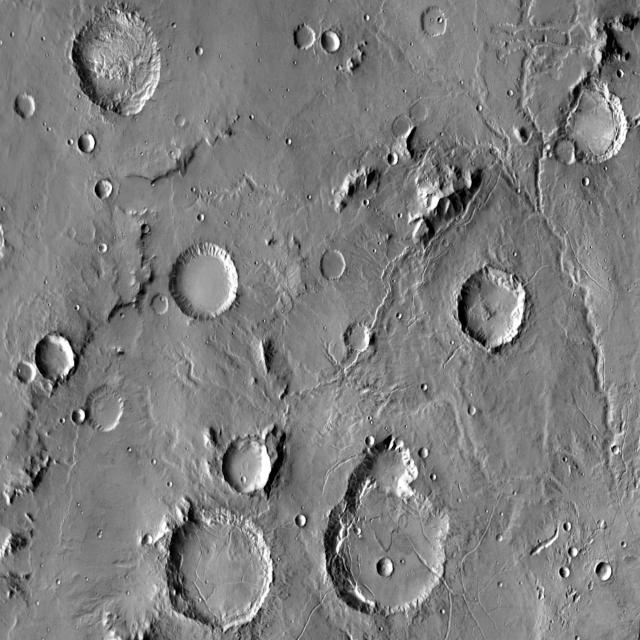

In [92]:
Image.open(images_path[1])

### data yaml

In [93]:
data_yaml = dataset_path  / 'data.yaml'
data_yaml

WindowsPath('C:/Users/Ronkin/Documents/GitHub/Deep-Learning-in-Image-Processing-Lectures/2025/craters/data.yaml')

In [94]:
import yaml

data = {
    f'train': str(dataset_path / 'train' / 'images'),
    f'val': str(dataset_path / 'valid' / 'images'),
    'nc': 1,
    'names': ['0']
}

with open(data_yaml, 'w') as file:
    yaml.safe_dump(data, file)

print("New YAML file created successfully.")

with open(data_yaml, 'r') as file:
    data=yaml.safe_load( file)
print(data)

New YAML file created successfully.
{'names': ['0'], 'nc': 1, 'train': 'C:\\Users\\Ronkin\\Documents\\GitHub\\Deep-Learning-in-Image-Processing-Lectures\\2025\\craters\\train\\images', 'val': 'C:\\Users\\Ronkin\\Documents\\GitHub\\Deep-Learning-in-Image-Processing-Lectures\\2025\\craters\\valid\\images'}


## dataset example

In [95]:
def yolo2coco(xc, yc, w, h, image_width, image_height):
    xc, w = xc*image_width,  w*image_width
    yc, h = yc*image_height, h*image_height
    xmin = xc - w//2
    ymin = yc - h//2
    return xmin,ymin,w, h

def plot_bbox(image_pth, ann_pth = None, predicted_boxes = None, pred_classes = None):
    image =  np.asarray(Image.open(image_pth))
    height, width = image.shape[:2]

    if ann_pth == None:
        ann_name = image_pth.parts[-1][:-4]+'.txt'
        ann_pth = Path(*image_pth.parts[:-2]) / 'labels'/ann_name
    data = pd.read_csv(ann_pth, sep=" ", header=None).values     
    
    bbox   = np.asarray(data)[:,1:5]
    
    fig, axs = plt.subplots(1, 2, figsize = (8,4))
    image_ = np.copy(image).astype(float)/image.max()
    
    # Ground Truth    
    axs[0].imshow(np.clip(image_,0,1), 'gray')
    axs[0].axis('off'); axs[0].set_title('Original Image')
    #----------------------------
    
    # Object Detection BBoxes
    axs[1].imshow(np.clip(image_,0,1), 'gray')
    
    for box in bbox:
        xmin,ymin,w,h = yolo2coco(*box, width,height)
        bb = patches.Rectangle(xy     = (xmin,ymin), 
                               width  = w,height = h, 
                               linewidth=2, edgecolor="blue", facecolor="none")
        axs[1].add_patch(bb)  

    if predicted_boxes != None:
        if pred_classes == None:
            pred_classes = ['0']*len(predicted_boxes)
        for cls,box in zip(np.array(pred_classes),np.array(predicted_boxes)):
            xmin,ymin,w,h = yolo2coco(*box, width,height)
            bb = patches.Rectangle(xy     = (xmin,ymin), 
                                   width  = w,height = h, 
                                   linewidth=2, edgecolor="red", facecolor="none")
            axs[1].add_patch(bb)


            axs[1].text(xmin,ymin,str(cls),fontsize=10, color="green", weight="bold")
    
    axs[1].axis('off'); axs[1].set_title('Object Detection')
    plt.tight_layout()
    plt.show()

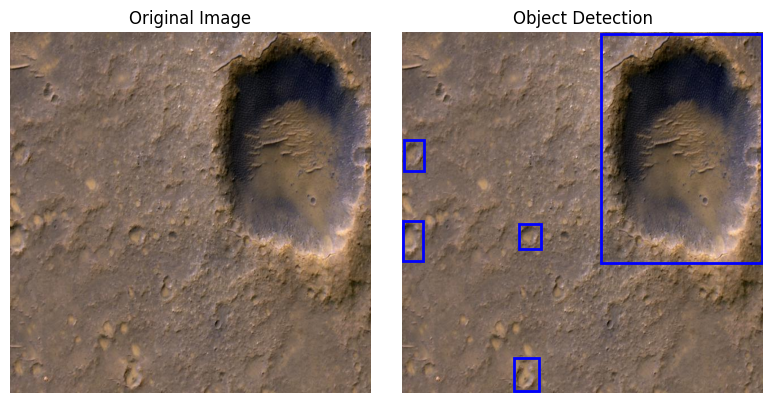

In [96]:
plot_bbox(images_path[47] )

## model

In [97]:
model = YOLO("yolov8n.pt")
results = model(images_path[47])


image 1/1 C:\Users\Ronkin\Documents\GitHub\Deep-Learning-in-Image-Processing-Lectures\2025\craters\train\images\mars_crater--35-_jpg.rf.826bc4b2a3a69c48144834f40d92439f.jpg: 640x640 (no detections), 12.4ms
Speed: 3.6ms preprocess, 12.4ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


In [98]:
def plot_result(result):
    image_pth = Path(result.path)
    image =  np.asarray(Image.open(image_pth))
    height, width = image.shape[:2]

    ann_name = image_pth.parts[-1][:-4]+'.txt'
    ann_pth = Path(*image_pth.parts[:-2]) / 'labels'/ann_name
    data = pd.read_csv(ann_pth, sep=" ", header=None).values     
    
    bbox   = np.asarray(data)[:,1:5]
    
    fig, axs = plt.subplots(1, 2, figsize = (8,4))
    image_ = np.copy(image).astype(float)/image.max()
    
    # Ground Truth    
    axs[0].imshow(np.clip(image_,0,1), 'gray')
    axs[0].axis('off'); axs[0].set_title('Original Image')
    #----------------------------
    
    # Object Detection BBoxes
    axs[1].imshow(np.clip(image_,0,1), 'gray')
    
    for box in bbox:
        xmin,ymin,w,h = yolo2coco(*box, width,height)
        bb = patches.Rectangle(xy     = (xmin,ymin), 
                               width  = w,height = h, 
                               linewidth=2, edgecolor="blue", facecolor="none")
        axs[1].add_patch(bb)  

    predicted_boxes = result.boxes.xywhn
    pred_classes = result.boxes.cls.long()
    if pred_classes == []:
        pred_classes = len(predicted_boxes)*['0']
    
    if predicted_boxes != None:
        if pred_classes == None:
            pred_classes = ['0']*len(predicted_boxes)
        
        for cls,box in zip(np.array(pred_classes),np.array(predicted_boxes)):
            xmin,ymin,w,h = yolo2coco(*box, width,height)
            bb = patches.Rectangle(xy     = (xmin,ymin), 
                                   width  = w,height = h, 
                                   linewidth=2, edgecolor="red", facecolor="none")
            axs[1].add_patch(bb)


            axs[1].text(xmin,ymin,str(cls),fontsize=10, color="green", weight="bold")
    
    axs[1].axis('off'); axs[1].set_title('Object Detection')
    plt.tight_layout()
    plt.show()

C:\Users\Ronkin\AppData\Local\Temp\ipykernel_16804\1480147465.py:39: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  for cls,box in zip(np.array(pred_classes),np.array(predicted_boxes)):


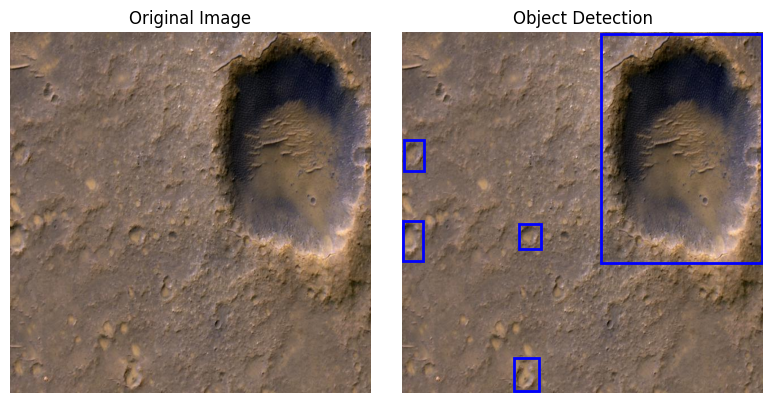

In [99]:
plot_result(results[0].cpu() )

## training

In [103]:
model = YOLO("yolov8n.pt")
results = model.train(data=data_yaml,imgsz=640, epochs = 5)

New https://pypi.org/project/ultralytics/8.3.146 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.127  Python-3.12.7 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Ronkin\Documents\GitHub\Deep-Learning-in-Image-Processing-Lectures\2025\craters\data.yaml, degrees=0.0, deterministic=True, device=cuda:0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mo

train: Scanning C:\Users\Ronkin\Documents\GitHub\Deep-Learning-in-Image-Processing-Lectures\2025\craters\train\labels.c

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access  (ping: 0.10.0 ms, read: 519.8124.0 MB/s, size: 71.8 KB)


val: Scanning C:\Users\Ronkin\Documents\GitHub\Deep-Learning-in-Image-Processing-Lectures\2025\craters\valid\labels.cac


...

        5/5      2.47G      1.532      1.799      1.285         21        640: 100%|██████████| 7/7 [00:00<00:00,  8.16
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<0

                   all         26        202     0.0221      0.851      0.284      0.175



5 epochs completed in 0.002 hours.
Optimizer stripped from runs\detect\train5\weights\last.pt, 6.2MB
Optimizer stripped from runs\detect\train5\weights\best.pt, 6.2MB

Validating runs\detect\train5\weights\best.pt...
Ultralytics 8.3.127  Python-3.12.7 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<0


                   all         26        202     0.0219      0.847      0.284      0.175
Speed: 0.2ms preprocess, 1.4ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs\detect\train5


## Results

In [110]:
results = model.val(data=data_yaml,imgsz=640)

Ultralytics 8.3.127  Python-3.12.7 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 635.2228.6 MB/s, size: 71.5 KB)


val: Scanning C:\Users\Ronkin\Documents\GitHub\Deep-Learning-in-Image-Processing-Lectures\2025\craters\valid\labels.cac
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<0


                   all         26        202     0.0218      0.842      0.284      0.175
Speed: 5.0ms preprocess, 9.5ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs\detect\train53


Measure

In [111]:
results.box.map50

np.float64(0.28416824938610885)

In [112]:
print(f'map 50:95 = {results.box.map:.3f}')  # map50-95

map 50:95 = 0.175


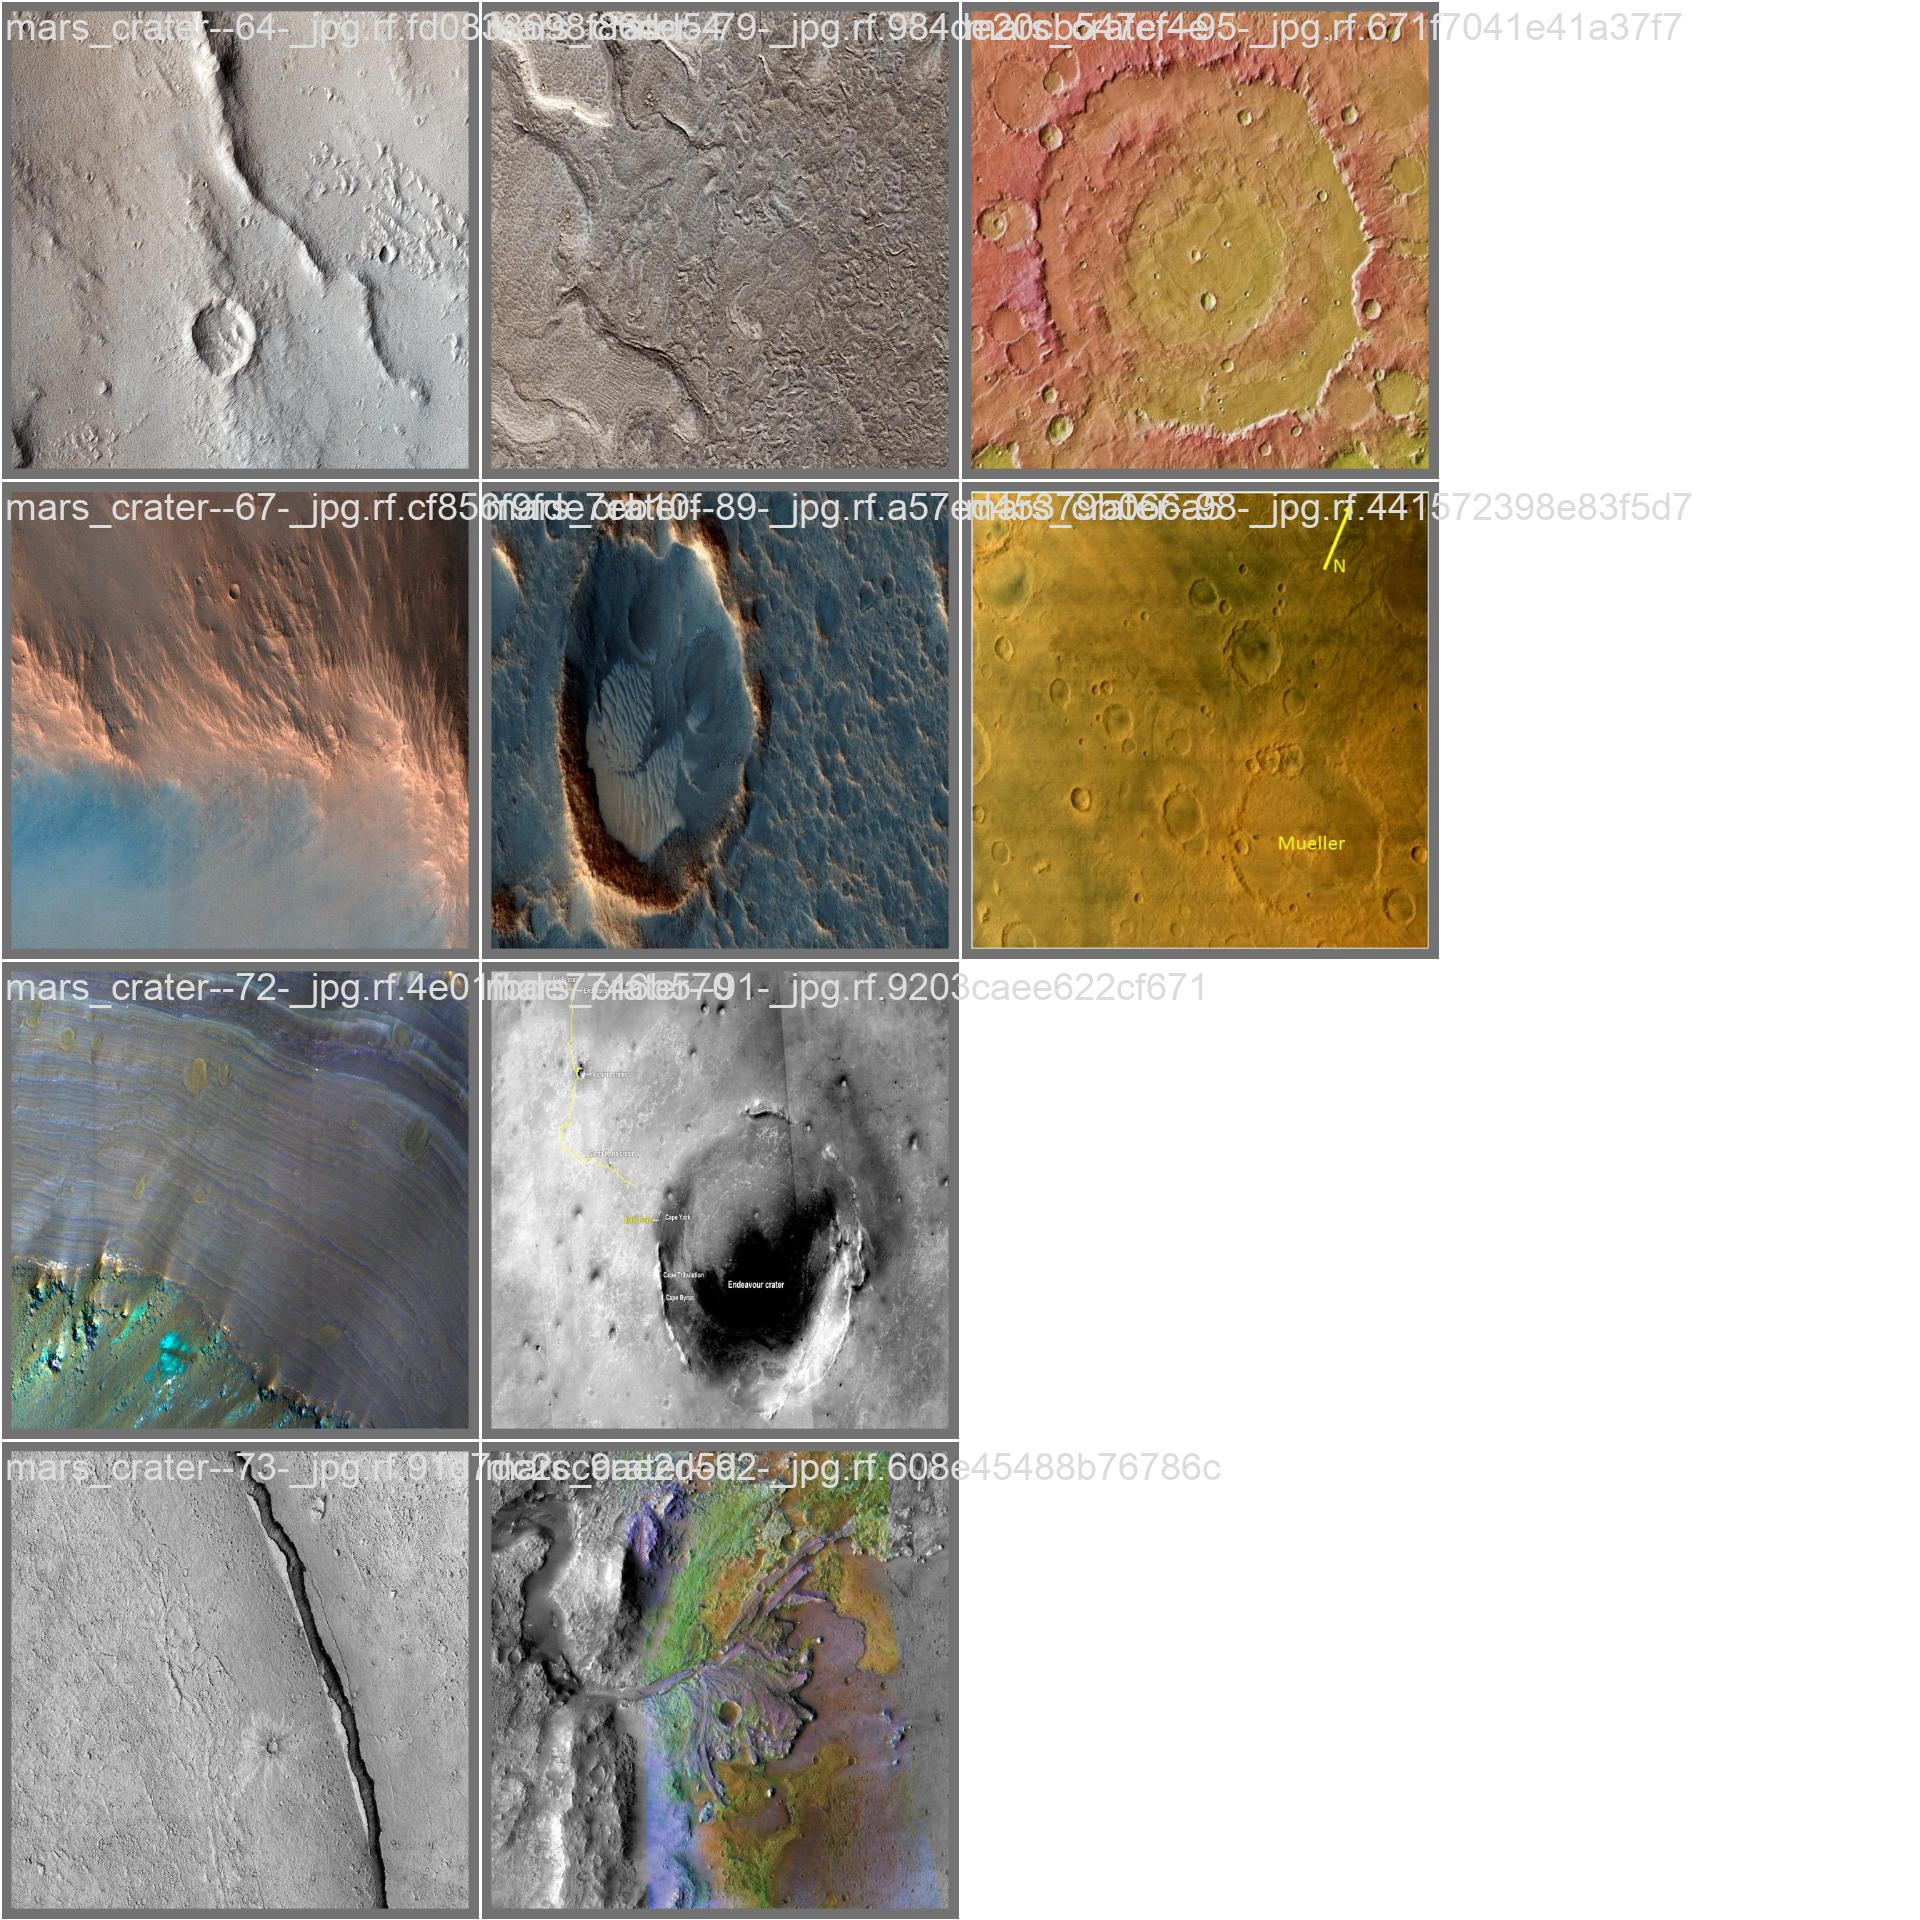

In [113]:
os.listdir(results.save_dir)
Image.open(os.path.join(str(results.save_dir),'val_batch1_pred.jpg'))

In [114]:
results = model(test_images_path[:], )


0: 640x640 (no detections), 9.2ms
1: 640x640 (no detections), 9.2ms
2: 640x640 (no detections), 9.2ms
3: 640x640 (no detections), 9.2ms
4: 640x640 (no detections), 9.2ms
5: 640x640 (no detections), 9.2ms
6: 640x640 (no detections), 9.2ms
7: 640x640 (no detections), 9.2ms
8: 640x640 (no detections), 9.2ms
9: 640x640 (no detections), 9.2ms
10: 640x640 (no detections), 9.2ms
11: 640x640 (no detections), 9.2ms
12: 640x640 (no detections), 9.2ms
13: 640x640 (no detections), 9.2ms
14: 640x640 (no detections), 9.2ms
15: 640x640 (no detections), 9.2ms
16: 640x640 (no detections), 9.2ms
17: 640x640 (no detections), 9.2ms
18: 640x640 (no detections), 9.2ms
Speed: 10.9ms preprocess, 9.2ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


## submission

* The model can be found in the training description - the `save_dir` parameter, for example, in the form `=runs\detect\train9`
* You can also change the directory to save the model as `settings.update({'runs_dir': '/path/to/runs'})`
* There will usually be two files in the directory `last.pt `and `best.pt `. Needed `best.pt `.
* File `best.pt `you need to save it under your own name and hand it over.
* You can check the model as shown below.
* Note that the uploaded model can also be retrained if desired.

In [115]:
save_dir = model.trainer.save_dir 
best_trained_weights = save_dir / 'weights' / 'best.pt'
best_trained_weights

WindowsPath('runs/detect/train5/weights/best.pt')

In [116]:
model = YOLO(best_trained_weights)  # load a partially trained model
# results = model.train(data=data_yaml,imgsz=640, epochs = 7)
results = model.val(data=data_yaml,imgsz=640)

Ultralytics 8.3.127  Python-3.12.7 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 567.5186.7 MB/s, size: 73.8 KB)


val: Scanning C:\Users\Ronkin\Documents\GitHub\Deep-Learning-in-Image-Processing-Lectures\2025\craters\valid\labels.cac
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<0


                   all         26        202     0.0218      0.842      0.284      0.175
Speed: 3.2ms preprocess, 6.2ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs\detect\val3


In [117]:
def round_(x, digits=2):
    return (x*100//1)/100
#-------------------------------------------------------------
def yolo_results(model, img_folder, n_imgs=2):
    if n_imgs is None:
        n_imgs = len(list(Path(img_folder).iterdir()))
    n_imgs = min(n_imgs, len(list(Path(img_folder).iterdir())))     
        
    img_paths = [x for x,_ in zip(Path(img_folder).iterdir(), range(n_imgs)) if str(x).endswith(('jpg','png'))]

    if not img_paths:
        print("Не найдены изображения в указанной директории.")
        return
    results = model.predict(img_paths, save=False) 
    return results
#-------------------------------------------------------------
def yolo_predicts(img_folder, results, n_imgs=None):

    if n_imgs is None:
        n_imgs = len(list(Path(img_folder).iterdir()))
    n_imgs = min(n_imgs, len(results), len(list(Path(img_folder).iterdir())))          
        
    img_paths = [x for x,_ in zip(Path(img_folder).iterdir(), range(n_imgs)) if str(x).endswith(('jpg','png'))]

    outputs = []
    if not img_paths:
        print("Не найдены изображения в указанной директории.")
        return outputs
    
    for img_path, result in zip(img_paths, results):
        # Создаем базовую структуру предсказаний
        output = yolo_predict_struct(img_path, result)
        outputs.append(output)
  
    return outputs
#---------------------------------------------------------
def yolo_predict_struct(img_path, result):

    img = Image.open(img_path)
    w, h = img.size
    
    output = {
        'name': img_path.stem,
        'size': [w, h],
        'predict': []
    }
    
    for box in result.boxes:
        # Координаты bounding box
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        cls = int(box.cls)
        conf = round_(float(box.conf))

        output['predict'].append([cls, conf, round_(x1), round_(y1), round_(x2), round_(y2)])
    
    return output

In [118]:
submit_img_folder = Path(dataset_path) / 'test' / 'images'
results = yolo_results(model, submit_img_folder, n_imgs=None)   
outs = yolo_predicts(submit_img_folder, results)


0: 640x640 (no detections), 2.1ms
1: 640x640 (no detections), 2.1ms
2: 640x640 (no detections), 2.1ms
3: 640x640 (no detections), 2.1ms
4: 640x640 (no detections), 2.1ms
5: 640x640 (no detections), 2.1ms
6: 640x640 (no detections), 2.1ms
7: 640x640 (no detections), 2.1ms
8: 640x640 (no detections), 2.1ms
9: 640x640 (no detections), 2.1ms
10: 640x640 (no detections), 2.1ms
11: 640x640 (no detections), 2.1ms
12: 640x640 (no detections), 2.1ms
13: 640x640 (no detections), 2.1ms
14: 640x640 (no detections), 2.1ms
15: 640x640 (no detections), 2.1ms
16: 640x640 (no detections), 2.1ms
17: 640x640 (no detections), 2.1ms
18: 640x640 (no detections), 2.1ms
Speed: 2.4ms preprocess, 2.1ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


In [119]:
import json

name_ = 'NAME'
filename = f'submit {name_}.json'

with open(filename, 'w') as f:
    json.dump(outs, f, indent=4)